# Графическое решение (Вариант 7)

**Целевая функция:**

$$
\min\; f(x_1,x_2)= -5x_1-2x_2+x_1^2-x_1x_2+x_2^2
$$

**Ограничения:**
- $15-2x_1-3x_2\ge 0$
- $x_1+2x_2-8=0$
- $x_1\ge 0$, $x_2\ge 0$

Ниже: строим допустимое множество и линии уровня, а также отмечаем **минимум** и **максимум** на допустимом множестве.

In [90]:
import numpy as np
import matplotlib.pyplot as plt

def f(x1, x2):
    return -5*x1 - 2*x2 + x1**2 - x1*x2 + x2**2

# Ограничения

def g1(x1, x2):
    return 15 - 2*x1 - 3*x2  # >= 0

def h2(x1, x2):
    return x1 + 2*x2 - 8     # = 0

def g3(x1, x2):
    return x1                # >= 0

def g4(x1, x2):
    return x2                # >= 0

# Равенство: x1 + 2x2 - 8 = 0  ->  x1 = 8 - 2x2
# После подстановки в неравенства получается отрезок: x2 ∈ [1, 4]

x2_min, x2_max = 1.0, 4.0
x2_seg = np.linspace(x2_min, x2_max, 2001)
x1_seg = 8 - 2*x2_seg

f_seg = f(x1_seg, x2_seg)
i_min = int(np.argmin(f_seg))
i_max = int(np.argmax(f_seg))

xmin = (float(x1_seg[i_min]), float(x2_seg[i_min]))
xmax = (float(x1_seg[i_max]), float(x2_seg[i_max]))

print(f"Отрезок: x2 ∈ [{x2_min:g}, {x2_max:g}], x1 = 8 - 2x2")
print(f"MIN: x = ({xmin[0]:.4f}, {xmin[1]:.4f}), f = {f(xmin[0], xmin[1]):.4f}")
print(f"MAX: x = ({xmax[0]:.4f}, {xmax[1]:.4f}), f = {f(xmax[0], xmax[1]):.4f}")


Отрезок: x2 ∈ [1, 4], x1 = 8 - 2x2
MIN: x = (3.4290, 2.2855), f = -12.5714
MAX: x = (0.0000, 4.0000), f = 8.0000


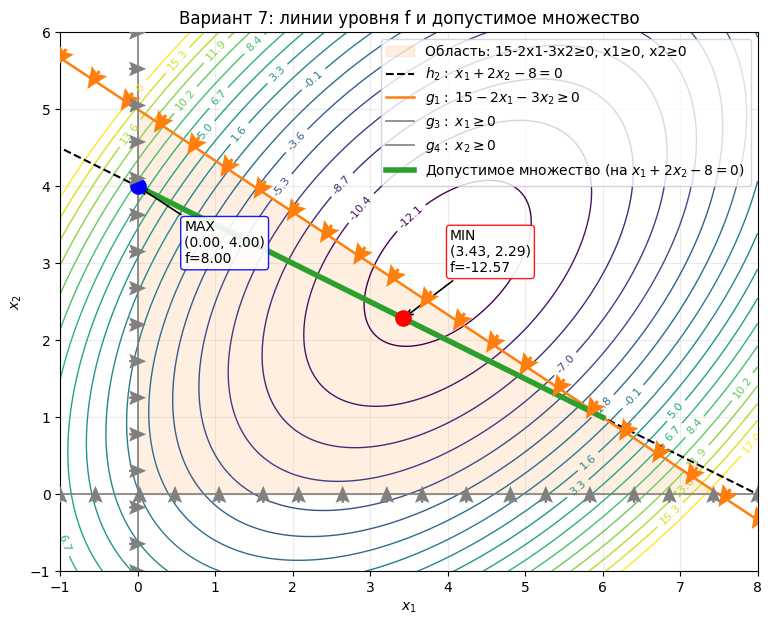

In [91]:
# График: линии уровня + границы + допустимое множество + MIN/MAX

# Сетка для контуров
x1 = np.linspace(-1, 8, 600)
x2 = np.linspace(-1, 6, 600)
X1, X2 = np.meshgrid(x1, x2)
F = f(X1, X2)

fig, ax = plt.subplots(figsize=(9, 7))

# Линии уровня f
levels = np.linspace(np.percentile(F, 5), np.percentile(F, 95), 18)
cs = ax.contour(X1, X2, F, levels=levels, linewidths=1.0)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

# Полупрозрачная область допустимых значений для НЕРАВЕНСТВ:
# x1>=0, x2>=0 и g1>=0 <=> x2 <= (15-2x1)/3
x1_fill = np.linspace(0, 8, 600)
x2_g1 = (15 - 2 * x1_fill) / 3
x2_g1_clip = np.clip(x2_g1, 0, 6)
ax.fill_between(
    x1_fill,
    0,
    x2_g1_clip,
    where=x2_g1 > 0,
    color="tab:orange",
    alpha=0.12,
    label="Область: 15-2x1-3x2≥0, x1≥0, x2≥0",
    zorder=0,
)

# Границы ограничений
# h2=0: x1 = 8 - 2x2
x2_line = np.linspace(-1, 6, 400)
ax.plot(8 - 2*x2_line, x2_line, "k--", lw=1.5, label=r"$h_2:\ x_1+2x_2-8=0$")

# g1>=0: 15 - 2x1 - 3x2 >= 0 (рисуем границу g1=0)
x1_line = np.linspace(-1, 8, 400)
ax.plot(
    x1_line,
    (15 - 2*x1_line)/3,
    color="tab:orange",
    lw=1.8,
    label=r"$g_1:\ 15-2x_1-3x_2\geq 0$",
)

# g3: x1>=0 и g4: x2>=0 (рисуем границы x1=0 и x2=0)
ax.axvline(0, color="gray", lw=1.2, label=r"$g_3:\ x_1\geq 0$")
ax.axhline(0, color="gray", lw=1.2, label=r"$g_4:\ x_2\geq 0$")

def add_boundary_arrows(ax, xs, ys, dx, dy, *, n=18, length=0.25, color="red", width=0.004, zorder=6):
    """Много маленьких стрелок вдоль границы, указывающих допустимую сторону."""
    xs = np.asarray(xs)
    ys = np.asarray(ys)
    if xs.size < 2:
        return

    idx = np.linspace(0, xs.size - 1, n).astype(int)
    xq = xs[idx]
    yq = ys[idx]

    norm = float((dx * dx + dy * dy) ** 0.5)
    if norm == 0:
        return
    ux, uy = dx / norm, dy / norm

    U = np.full_like(xq, ux * length, dtype=float)
    V = np.full_like(yq, uy * length, dtype=float)

    ax.quiver(
        xq,
        yq,
        U,
        V,
        angles="xy",
        scale_units="xy",
        scale=1,
        width=width,
        color=color,
        zorder=zorder,
        pivot="mid",
        headwidth=6,
        headlength=7,
        headaxislength=6,
    )


# Маленькие стрелочки вдоль границ (как в примере)
# g1>=0 соответствует 2x1+3x2 <= 15, поэтому направление в допустимую область: (-2, -3)
y_g1 = (15 - 2 * x1_line) / 3
mask = (y_g1 >= -1) & (y_g1 <= 6)
add_boundary_arrows(
    ax,
    x1_line[mask],
    y_g1[mask],
    dx=-2,
    dy=-3,
    n=22,
    length=0.28,
    color="tab:orange",
    width=0.0045,
)

# g3: x1>=0 (граница x1=0), стрелки вправо
_yv = np.linspace(-1, 6, 60)
_xv = np.zeros_like(_yv)
add_boundary_arrows(ax, _xv, _yv, dx=1, dy=0, n=16, length=0.22, color="gray", width=0.004)

# g4: x2>=0 (граница x2=0), стрелки вверх
_xh = np.linspace(-1, 8, 80)
_yh = np.zeros_like(_xh)
add_boundary_arrows(ax, _xh, _yh, dx=0, dy=1, n=18, length=0.22, color="gray", width=0.004)

# Допустимый отрезок (пересечение всех ограничений)
ax.plot(
    x1_seg,
    x2_seg,
    color="tab:green",
    lw=4,
    label=r"Допустимое множество (на $x_1+2x_2-8=0$)",
)

# Точки минимума и максимума на допустимом множестве
ax.scatter([xmin[0]], [xmin[1]], s=120, color="red", zorder=5)
ax.scatter([xmax[0]], [xmax[1]], s=120, color="blue", zorder=5)

ax.annotate(
    f"MIN\n({xmin[0]:.2f}, {xmin[1]:.2f})\nf={f(xmin[0], xmin[1]):.2f}",
    xy=xmin,
    xytext=(xmin[0] + 0.6, xmin[1] + 0.6),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="red", alpha=0.9),
)

ax.annotate(
    f"MAX\n({xmax[0]:.2f}, {xmax[1]:.2f})\nf={f(xmax[0], xmax[1]):.2f}",
    xy=xmax,
    xytext=(xmax[0] + 0.6, xmax[1] - 1.0),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="blue", alpha=0.9),
)

ax.set_title("Вариант 7: линии уровня f и допустимое множество")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_xlim(-1, 8)
ax.set_ylim(-1, 6)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")

plt.show()


## Комбинированный метод (код)

Ниже реализован комбинированный метод для минимизации штрафной функции

$$
P(X,r)=f(x_1,x_2)+\frac{1}{\sqrt r}(x_1+2x_2-8)^2+r\left(\frac{1}{15-2x_1-3x_2}+\frac{1}{x_1}+\frac{1}{x_2}\right).
$$

- Внешний цикл: уменьшаем $r$.
- Внутренний цикл: минимизируем $P(X,r)$ градиентным методом; длина шага — **правило Армихо** (backtracking) по нормированному антиградиенту, с проверкой внутренней допустимости (барьер).

В конце строится 3D‑модель (поверхность $f$, плоскость $h_2=0$) и **восемь траекторий**: для каждого из двух экспериментов — кривая на $f$ и на $P$, отдельно для **Армихо** и для **Вульфа** (разные цвета в легенде). **Сводная таблица** тоже сравнивает оба правила шага. Печатаются блоки **«Решение задачи на ЭВМ»** для **каждого** эксперимента и **обоих** правил шага: старт, итерации по каждому $r$, итог с проверками и теоретическим оптимумом варианта 7.

In [92]:
import numpy as np
import matplotlib.pyplot as plt

# --- Задача (вариант 7) ---

def f(x1, x2):
    return -5*x1 - 2*x2 + x1**2 - x1*x2 + x2**2

def h2(x1, x2):
    return x1 + 2*x2 - 8

def g1(x1, x2):
    return 15 - 2*x1 - 3*x2

def P(x1, x2, r):
    # Важно: P определена только внутри области g1>0, x1>0, x2>0
    return (
        f(x1, x2)
        + (1/np.sqrt(r)) * (h2(x1, x2)**2)
        + r * (1/g1(x1, x2) + 1/x1 + 1/x2)
    )

# Градиент P (полностью через x1,x2,r)

def gradP(x1, x2, r):
    g = g1(x1, x2)
    h = h2(x1, x2)
    dPdx1 = (
        (-5 + 2*x1 - x2)
        + (2/np.sqrt(r)) * h
        + (2*r)/(g**2)
        - r/(x1**2)
    )
    dPdx2 = (
        (-2 - x1 + 2*x2)
        + (4/np.sqrt(r)) * h
        + (3*r)/(g**2)
        - r/(x2**2)
    )
    return np.array([dPdx1, dPdx2], dtype=float)


def feasible(x1, x2, eps=1e-9):
    return (x1 > eps) and (x2 > eps) and (g1(x1, x2) > eps)


def line_search_wolfe(
    x,
    d,
    r,
    g,
    *,
    c1=1e-4,
    c2=0.99,
    alpha_max=1.0,
    rho=0.5,
    max_iter=100,
    alpha_min=1e-12,
    alpha_curv_floor=1e-8,
    curvature_expand=1.5,
    alpha_init=None,
):
    """Линейный поиск по условиям Вульфа (Армихо + слабое условие кривизны).

    x — текущая точка (массив из 2), d — направление (единичный),
    g = gradP(x). Дополнительно: точка должна оставаться внутренней (barrier).
    При alpha <= alpha_curv_floor после Армихо кривизну не проверяем (только Армихо).
    При провале кривизны: alpha <- min(alpha_max, curvature_expand * alpha).
    alpha_init: начальное пробное alpha; None — брать alpha_max; иначе min(alpha_max, alpha_init).
    """
    P_curr = float(P(x[0], x[1], r))
    g_dot_d = float(np.dot(g, d))
    if alpha_init is None:
        alpha = float(alpha_max)
    else:
        ai = float(alpha_init)
        alpha = float(alpha_max) if (not np.isfinite(ai) or ai <= 0) else min(float(alpha_max), ai)

    for ls_it in range(max_iter):
        x_new = x + alpha * d
        if not feasible(x_new[0], x_new[1]):
            alpha_prev = alpha
            alpha *= rho
            if alpha < alpha_min:
                return None
            continue

        P_new = float(P(x_new[0], x_new[1], r))
        # 1) Армихо (достаточное убывание)
        if P_new > P_curr + c1 * alpha * g_dot_d:
            alpha_prev = alpha
            alpha *= rho
            if alpha < alpha_min:
                return None
            continue

        g_new = gradP(x_new[0], x_new[1], r)
        gd_new = float(np.dot(g_new, d))
        curv_rhs = c2 * g_dot_d
        # 2) Слабое условие кривизны
        if gd_new < curv_rhs:
            if alpha < alpha_max:
                alpha_prev = alpha
                alpha = min(alpha_max, alpha * curvature_expand)
                continue
            return alpha
        return alpha

    return alpha


def gradient_descent_for_fixed_r(
    x0,
    r,
    *,
    max_iter=5000,
    grad_tol=1e-3,
    alpha0=1.0,
    c1=1e-4,
    c2=0.99,
    beta=0.5,
    alpha_min=1e-8,
    curvature_expand=1.5,
    line_search="armijo",
    wolfe_warm_factor=1.5,
    verbose=False,
):
    """Минимизируем P(x,r) градиентным спуском при фиксированном r.

    Шаг по линии: x_new = x + alpha * d, d = -g/||g||.
    line_search=\"armijo\" — только Армихо (backtracking).
    line_search=\"wolfe\" — условия Вульфа (Армихо + слабое условие кривизны), см. line_search_wolfe.
    Для Wolfe: warm start min(alpha0, alpha_prev*wolfe_warm_factor), alpha_prev — принятый шаг на прошлой итерации.
    Дополнительно точка остаётся внутри области (g1>0, x1>0, x2>0).
    """
    x = np.array(x0, dtype=float)
    if not feasible(x[0], x[1]):
        raise ValueError(f"Начальная точка недопустима: x={x}")

    hist = {
        "x": [x.copy()],
        "f": [float(f(x[0], x[1]))],
        "P": [float(P(x[0], x[1], r))],
        "grad_norm": [],
    }

    alpha_prev_wolfe = None

    for k in range(max_iter):
        g = gradP(x[0], x[1], r)
        gn = float(np.linalg.norm(g))
        hist["grad_norm"].append(gn)
        if verbose and (k % 10 == 0):
            print(
                f"  iter {k:2d}: X=({x[0]:.4f}, {x[1]:.4f}), ||grad||={gn:.2e}"
            )
        if gn < grad_tol:
            if verbose:
                print(f"  Сошлись за {k + 1} итераций")
            break

        # Направление антиградиента (единичный вектор)
        d = -g / gn
        g_dot_d = float(np.dot(g, d))

        success = False
        x_try = None

        if line_search == "armijo":
            P_curr = float(P(x[0], x[1], r))
            a = float(alpha0)
            for _ls in range(80):
                x_try = x + a * d
                if not feasible(x_try[0], x_try[1]):
                    a *= beta
                    if a < alpha_min:
                        break
                    continue

                P_try = float(P(x_try[0], x_try[1], r))
                if P_try <= P_curr + c1 * a * g_dot_d:
                    success = True
                    break

                a *= beta
                if a < alpha_min:
                    break

        elif line_search == "wolfe":
            alpha_init = None
            if alpha_prev_wolfe is not None:
                alpha_init = min(alpha0, alpha_prev_wolfe * wolfe_warm_factor)
            a = line_search_wolfe(
                x,
                d,
                r,
                g,
                c1=c1,
                c2=c2,
                alpha_max=alpha0,
                rho=beta,
                max_iter=100,
                alpha_min=alpha_min,
                curvature_expand=curvature_expand,
                alpha_init=alpha_init,
            )
            if a is not None and a >= alpha_min:
                x_try = x + a * d
                success = feasible(x_try[0], x_try[1])

        if not success or x_try is None:
            if verbose:
                print(f"  Остановка: линейный поиск не удался (итерация {k + 1})")
            break

        x = x_try
        if line_search == "wolfe" and a is not None:
            alpha_prev_wolfe = float(a)
        hist["x"].append(x.copy())
        hist["f"].append(float(f(x[0], x[1])))
        hist["P"].append(float(P(x[0], x[1], r)))

    return x, hist


def combined_method(
    x0,
    *,
    r0=10.0,
    r_factor=0.25,
    r_min=1e-4,
    theta0=1e-5,
    eps_grad=1e-3,
    line_search="armijo",
    verbose=False,
    verbose_subtitle="",
):
    """Комбинированный метод: внешний цикл по r, внутри — градиентный спуск P."""
    r = float(r0)
    x = np.array(x0, dtype=float)

    if verbose:
        title = "Решение задачи на ЭВМ"
        if verbose_subtitle:
            title += f" — {verbose_subtitle}"
        print(title)
        print()
        xi, xj = float(x[0]), float(x[1])
        print(f"Начальная точка: ({xi:g}, {xj:g})")
        print(f"f = {f(xi, xj):g}")
        print(f"h2 = x1 + 2x2 - 8 = {h2(xi, xj):g}")
        print(f"g1 = 15 - 2x1 - 3x2 = {g1(xi, xj):g}")
        print(f"P(X, r) = {P(xi, xj, r)}")
        print()

    all_hist = {
        "x": [],
        "f": [],
        "P": [],
        "r": [],
        "outer": [],
        # сумма итераций внутреннего цикла (шаг +1 на каждую оценку ∇P) по всем r
        "steps_total": 0,
    }

    outer_k = 0
    while r >= r_min:
        if verbose:
            print(f"r = {r}")
        x, hist_inner = gradient_descent_for_fixed_r(
            x,
            r,
            grad_tol=eps_grad,
            line_search=line_search,
            verbose=verbose,
        )

        inner_steps = len(hist_inner["grad_norm"])
        all_hist["steps_total"] += inner_steps

        j0 = 0 if outer_k == 0 else 1
        for j in range(j0, len(hist_inner["x"])):
            all_hist["x"].append(hist_inner["x"][j])
            all_hist["f"].append(hist_inner["f"][j])
            all_hist["P"].append(hist_inner["P"][j])
            all_hist["r"].append(r)
            all_hist["outer"].append(outer_k)

        # критерий внешнего цикла: P близко к f и r достаточно мало
        if verbose:
            xf, yf = float(x[0]), float(x[1])
            print(f"  X = ({xf:.6f}, {yf:.6f})")
            print(f"  f = {f(xf, yf):.6f}")
            print(f"  h2 = {h2(xf, yf):.2e}")
            print(f"  g1 = {g1(xf, yf):.2e}")
            print(f"P(X, r) = {P(xf, yf, r)}")
            print()

        if abs(all_hist["P"][-1] - all_hist["f"][-1]) <= theta0 and r < 1e-2:
            break

        r *= r_factor
        outer_k += 1

    if verbose:
        print("Итог")
        xf, yf = float(x[0]), float(x[1])
        print(f"X* = ({xf:.6f}, {yf:.6f})")
        print(f"f* = {f(xf, yf):.6f}")
        print(f"Проверка x1 + 2x2 - 8 = {h2(xf, yf):.2e}")
        print(f"Проверка 15 - 2x1 - 3x2 = {g1(xf, yf):.2e}")
        x1t, x2t = 24.0 / 7.0, 16.0 / 7.0
        ft = -88.0 / 7.0
        print(
            f"Теоретический оптимум: ({x1t:.6f}, {x2t:.6f}), f = {ft:.6f}"
        )
        print(f"{int(all_hist['steps_total'])} кол-во итераций")
        print()

    return x, all_hist


# --- Эксперименты (2 начальные точки внутри области) ---
experiments = [
    {"id": 1, "x0": (4.0, 1.0)},
    {"id": 2, "x0": (2.0, 2.0)},
]

results_armijo = []
results_wolfe = []
all_runs_armijo = []
all_runs_wolfe = []

# Для каждой x0: отдельные полные прогоны комбинированного метода — сначала с line_search="armijo",
# затем с line_search="wolfe" (в gradient_descent_for_fixed_r ветки if line_search == "armijo" / "wolfe").
_need_sep_report = False
for exp in experiments:
    x0 = exp["x0"]
    if not feasible(x0[0], x0[1]):
        raise ValueError(
            f"Эксперимент {exp['id']}: точка x0={x0} недопустима (g1={g1(x0[0], x0[1]):.4f})"
        )

    _line_search_steps = (
        (
            "armijo",
            results_armijo,
            all_runs_armijo,
            "правило Армихо (backtracking)",
            "Армихо",
        ),
        (
            "wolfe",
            results_wolfe,
            all_runs_wolfe,
            "условия Вульфа (Армихо + кривизна)",
            "Вульф",
        ),
    )
    for line_search_kind, results_list, runs_list, method_ru, method_short in _line_search_steps:
        if _need_sep_report:
            print("\n" + "=" * 72 + "\n")
        _need_sep_report = True

        x_star, hist = combined_method(
            x0,
            r0=10.0,
            line_search=line_search_kind,
            verbose=True,
            verbose_subtitle=f"эксперимент {exp['id']}, {method_ru}",
        )

        res = {
            "метод": method_short,
            "№ экс.": exp["id"],
            "x1_0": x0[0],
            "x2_0": x0[1],
            "x1*": float(x_star[0]),
            "x2*": float(x_star[1]),
            "f(x*)": float(f(x_star[0], x_star[1])),
            "P(x*,r_last)": float(hist["P"][-1]),
            "r_last": float(hist["r"][-1]),
            "итераций": int(hist.get("steps_total", max(0, len(hist["x"]) - 1))),
        }

        results_list.append(res)
        runs_list.append({"exp": exp, "hist": hist})

# для ячейки 3D: all_runs_armijo и all_runs_wolfe (траектории f и P)
all_runs = all_runs_armijo
results = results_armijo


Решение задачи на ЭВМ — эксперимент 1, правило Армихо (backtracking)

Начальная точка: (4, 1)
f = -9
h2 = x1 + 2x2 - 8 = -2
g1 = 15 - 2x1 - 3x2 = 4
P(X, r) = 7.264911064067352

r = 10.0
  iter  0: X=(4.0000, 1.0000), ||grad||=1.47e+01
  iter 10: X=(2.9835, 2.1018), ||grad||=9.35e-02
  Сошлись за 19 итераций
  X = (2.997447, 2.098732)
  f = -12.086172
  h2 = -8.05e-01
  g1 = 2.71e+00
P(X, r) = -0.0887277179379602

r = 2.5
  iter  0: X=(2.9974, 2.0987), ||grad||=2.94e+00
  iter 10: X=(3.2322, 2.2199), ||grad||=1.15e-02
  Сошлись за 16 итераций
  X = (3.229615, 2.220805)
  f = -12.399642
  h2 = -3.29e-01
  g1 = 1.88e+00
P(X, r) = -9.100522409090487

r = 0.625
  iter  0: X=(3.2296, 2.2208), ||grad||=2.42e+00
  iter 10: X=(3.3694, 2.3001), ||grad||=3.35e-02
  Сошлись за 16 итераций
  X = (3.370907, 2.301227)
  f = -12.555551
  h2 = -2.66e-02
  g1 = 1.35e+00
P(X, r) = -11.636226410932714

r = 0.15625
  iter  0: X=(3.3709, 2.3012), ||grad||=9.74e-01
  iter 10: X=(3.4198, 2.3067), ||grad||=2.2

In [93]:
# Табличка результатов (текстом, как в терминале)

def format_table(headers, rows):
    # widths
    widths = [len(h) for h in headers]
    for row in rows:
        for i, cell in enumerate(row):
            widths[i] = max(widths[i], len(str(cell)))

    def fmt_row(row):
        return "| " + " | ".join(str(cell).ljust(widths[i]) for i, cell in enumerate(row)) + " |"

    sep = "| " + " | ".join("-" * w for w in widths) + " |"

    out = [fmt_row(headers), sep]
    out += [fmt_row(r) for r in rows]
    return "\n".join(out)


headers = [
    "Лин. поиск",
    "Эксп.",
    "x1₀",
    "x2₀",
    "x1*",
    "x2*",
    "f(x*)",
    "P(x*, r)",
    "r (посл.)",
    "итерации",
]

rows = []
for r in results_armijo + results_wolfe:
    rows.append([
        r["метод"],
        r["№ экс."],
        f"{r['x1_0']:.3f}",
        f"{r['x2_0']:.3f}",
        f"{r['x1*']:.4f}",
        f"{r['x2*']:.4f}",
        f"{r['f(x*)']:.4f}",
        f"{r['P(x*,r_last)']:.4f}",
        f"{r['r_last']:.2e}",
        r["итераций"],
    ])

print("Сравнение: правило Армихо vs условия Вульфа (комбинированный метод, одни и те же x0):")
print(format_table(headers, rows))


Сравнение: правило Армихо vs условия Вульфа (комбинированный метод, одни и те же x0):
| Лин. поиск | Эксп. | x1₀   | x2₀   | x1*    | x2*    | f(x*)    | P(x*, r) | r (посл.) | итерации |
| ---------- | ----- | ----- | ----- | ------ | ------ | -------- | -------- | --------- | -------- |
| Армихо     | 1     | 4.000 | 1.000 | 3.4293 | 2.2867 | -12.5726 | -12.5718 | 1.53e-04  | 935      |
| Армихо     | 2     | 2.000 | 2.000 | 3.4293 | 2.2867 | -12.5726 | -12.5718 | 1.53e-04  | 972      |
| Вульф      | 1     | 4.000 | 1.000 | 3.4295 | 2.2865 | -12.5726 | -12.5718 | 1.53e-04  | 259      |
| Вульф      | 2     | 2.000 | 2.000 | 3.4295 | 2.2865 | -12.5726 | -12.5718 | 1.53e-04  | 260      |


In [94]:
# Интерактивный 3D-график (можно крутить мышкой)
# Используем Plotly (если не установлен, установи: pip install plotly)

try:
    import plotly.graph_objects as go
except ImportError as e:
    raise ImportError(
        "Plotly не установлен. Установи командой: pip install plotly"
    ) from e

# Поверхность f(x1,x2)
x1_grid = np.linspace(0.0, 6.5, 90)
x2_grid = np.linspace(0.0, 5.0, 101)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Zf = f(X1, X2)

fig = go.Figure()

fig.add_trace(
    go.Surface(
        x=X1,
        y=X2,
        z=Zf,
        colorscale="Viridis",
        opacity=0.60,
        name=f"f(x1,x2), сетка {Zf.size} точек",
        showscale=False,
    )
)

# Вертикальная плоскость x1 + 2*x2 - 8 = 0 (то же множество в (x1,x2), z свободно)
z_plane = np.linspace(float(Zf.min()), float(Zf.max()), 55)
x2_plane = np.linspace(0.0, 5.0, 55)
X2_p, Z_p = np.meshgrid(x2_plane, z_plane)
X1_p = 8.0 - 2.0 * X2_p
fig.add_trace(
    go.Surface(
        x=X1_p,
        y=X2_p,
        z=Z_p,
        surfacecolor=np.zeros_like(X1_p),
        colorscale=[[0, "rgba(255, 140, 0, 0.55)"], [1, "rgba(255, 140, 0, 0.55)"]],
        cmin=0,
        cmax=1,
        showscale=False,
        opacity=0.42,
        name=f"h2: x1+2x2-8=0, сетка {X1_p.size} точек",
        hovertemplate="x1=%{x:.3f}<br>x2=%{y:.3f}<br>z=%{z:.3f}<extra></extra>",
    )
)

# MIN / MAX как на 2D контуре (вар. 7): MAX (0, 4), f=8; MIN — безусловный минимум f в (24/7, 16/7).
x1_min_f, x2_min_f = 24.0 / 7.0, 16.0 / 7.0
z_min_f = float(f(x1_min_f, x2_min_f))
x1_max_f, x2_max_f = 0.0, 4.0
z_max_f = float(f(x1_max_f, x2_max_f))
fig.add_trace(
    go.Scatter3d(
        x=[x1_min_f],
        y=[x2_min_f],
        z=[z_min_f],
        mode="markers",
        marker=dict(
            size=12,
            symbol="circle",
            color="#e41a1c",
            line=dict(width=2, color="black"),
        ),
        name=f"MIN f (контур): ({x1_min_f:.2f}, {x2_min_f:.2f}), f={z_min_f:.2f}",
    )
)
fig.add_trace(
    go.Scatter3d(
        x=[x1_max_f],
        y=[x2_max_f],
        z=[z_max_f],
        mode="markers",
        marker=dict(
            size=12,
            symbol="circle",
            color="#377eb8",
            line=dict(width=2, color="black"),
        ),
        name=f"MAX f (контур): (0, 4), f={z_max_f:.2f}",
    )
)

# На 3D — по эксперименту две кривые f и P; отдельно прогоны Армихо и Вульфа (разные цвета).
_traj_specs = (
    (
        all_runs_armijo,
        "Армихо",
        {1: "red", 2: "deepskyblue"},
        {1: "darkred", 2: "blue"},
        5,
        4,
    ),
    (
        all_runs_wolfe,
        "Вульф",
        {1: "#e377c2", 2: "#ff7f0e"},
        {1: "#7b3294", 2: "#a65628"},
        4,
        3,
    ),
)
for all_runs, method_tag, palette_f, palette_P, lw_f, lw_P in _traj_specs:
    for run in all_runs:
        hist = run["hist"]
        xs = np.array(hist["x"])
        x1s, x2s = xs[:, 0], xs[:, 1]
        z_f = np.array(hist["f"])
        z_P = np.array(hist["P"])
        n_pts = len(x1s)

        exp_id = run["exp"]["id"]
        exp_key = (
            int(exp_id)
            if isinstance(exp_id, (int, str)) and str(exp_id).isdigit()
            else exp_id
        )
        c_f = palette_f.get(exp_key, "black")
        c_P = palette_P.get(exp_key, "gray")

        fig.add_trace(
            go.Scatter3d(
                x=x1s,
                y=x2s,
                z=z_f,
                mode="lines+markers",
                marker=dict(size=3, color=c_f),
                line=dict(width=lw_f, color=c_f),
                name=f"эксп. {exp_id}: f(x), {method_tag} (n={n_pts})",
            )
        )
        fig.add_trace(
            go.Scatter3d(
                x=x1s,
                y=x2s,
                z=z_P,
                mode="lines+markers",
                marker=dict(size=3, color=c_P),
                line=dict(width=lw_P, color=c_P),
                name=f"эксп. {exp_id}: P(x,r), {method_tag} (n={n_pts})",
            )
        )

fig.update_layout(
    title="Результаты оптимизации",
    width=1050,
    height=650,
    scene=dict(
        xaxis_title="x1",
        yaxis_title="x2",
        zaxis_title="значение",
    ),
    legend=dict(x=1.02, y=1.0),
    margin=dict(l=0, r=260, t=60, b=0),
)

# Показ в браузере (не требует nbformat)
import plotly.io as pio

pio.renderers.default = "browser"
fig.show()


In [95]:
# Функция Букина N. 6
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio


def bukin_6(x1, x2):
    """f = 100*sqrt(|x2 - 0.01*x1^2|) + 0.01*|x1+10|; глобальный минимум (-10, 1), f=0."""
    return (
        100.0 * np.sqrt(np.abs(x2 - 0.01 * np.square(x1)))
        + 0.01 * np.abs(x1 + 10.0)
    )


# Сетка так, чтобы (-10, 1) были узлами: иначе Surface интерполирует между соседями
# с f>0, и точка z=0 оказывается «под» поверхностью.
x1 = np.linspace(-15.0, -5.0, 221)
x2 = np.linspace(-3.0, 3.0, 220)
X1, X2 = np.meshgrid(x1, x2, indexing="xy")
Z = bukin_6(X1, X2)

fig = go.Figure()
fig.add_trace(
    go.Surface(
        x=X1,
        y=X2,
        z=Z,
        colorscale="Viridis",
        name="Bukin N.6",
        showscale=True,
        colorbar=dict(title="f"),
    )
)
fig.add_trace(
    go.Scatter3d(
        x=[-10.0],
        y=[1.0],
        z=[0.0],
        mode="markers",
        marker=dict(
            size=11,
            color="#e41a1c",
            symbol="diamond",
            line=dict(width=1.5, color="black"),
        ),
        name="глобальный минимум: (-10, 1), f = 0",
    )
)
fig.update_layout(
    title="Функция Букина N. 6",
    width=1000,
    height=720,
    scene=dict(
        xaxis_title="x1",
        yaxis_title="x2",
        zaxis_title="f(x1, x2)",
        camera=dict(eye=dict(x=1.35, y=-1.65, z=0.55)),
    ),
)
pio.renderers.default = "browser"
fig.show()